In [21]:
%load_ext autoreload
%autoreload 2
# Libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import shap
import captum
# Bundle net repo
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, project_into_latent_space
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser
# xai methods .py documents
from xai_methods import BehaviorWrapper, get_integrated_gradients
from xai_visualizations import plot_global_importance, plot_transition_heatmap


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


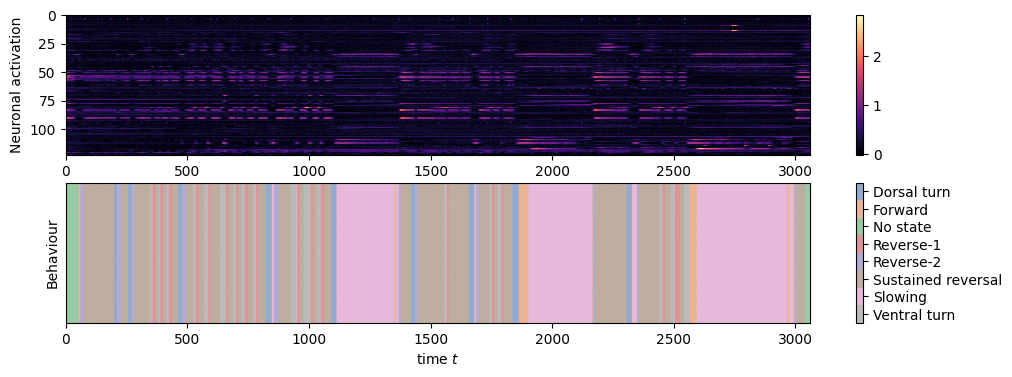

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [2]:
worm_num = 2
algorithm = 'BunDLe-Net'
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = "C:/Users/olgas/OneDrive/Documents/GitHub/Bundle-Net-Project/dataset/c_elegans/NoStim_Data.mat"
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour

plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names, cmap='magma')

In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
b = label_encoder.fit_transform(b)
print(x.shape, b.shape)
x_, b_ = prep_data(x, b, win=1)
print(x_.shape, b_.shape)

(3059, 123) (3059,)
(3058, 2, 1, 123) (3058,)


In [4]:
model = BunDLeNet(latent_dim=3, num_behaviour=len(data.behaviour_names), input_shape=x_.shape)
loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='discrete',
    gamma=0.9,
    learning_rate=0.001,
    n_epochs=500
)

Loss [Markov, Behaviour, Total]: [0.0093 0.0071 0.0164]: 100%|██████████| 500/500 [01:25<00:00,  5.86it/s]


In [10]:
# Wyciągamy tylko X_t (wymiar: [liczba_okien, okno_czasowe, liczba_neuronów])
x_t_only = x_[:, 0, :, :]

# Tworzymy tensor (upewnij się, że x_t_only jest tablicą numpy, np. poprzez x_t_only.copy() jeśli to konieczne)
x_tensor = torch.tensor(x_t_only, dtype=torch.float32, requires_grad=True)

# Uruchamiamy IG dla wybranej klasy (np. 1)
ig_attr = get_integrated_gradients(model, x_tensor, target_class=1)

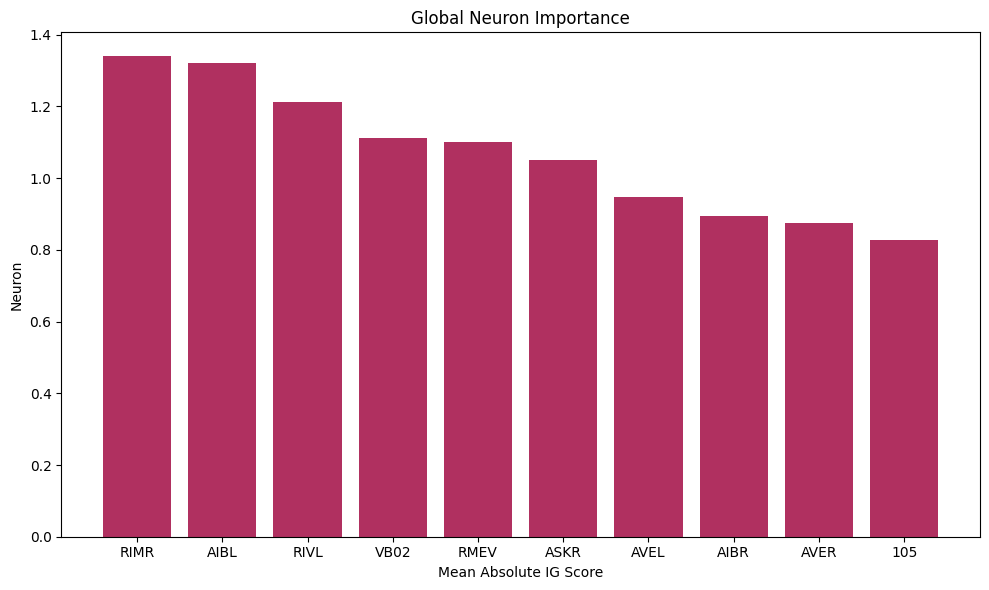

In [18]:
plot_global_importance(ig_attr,data.neuron_names, top_n = 10)

Moment przejścia: indeks 1. Zmiana na zachowanie nr 2


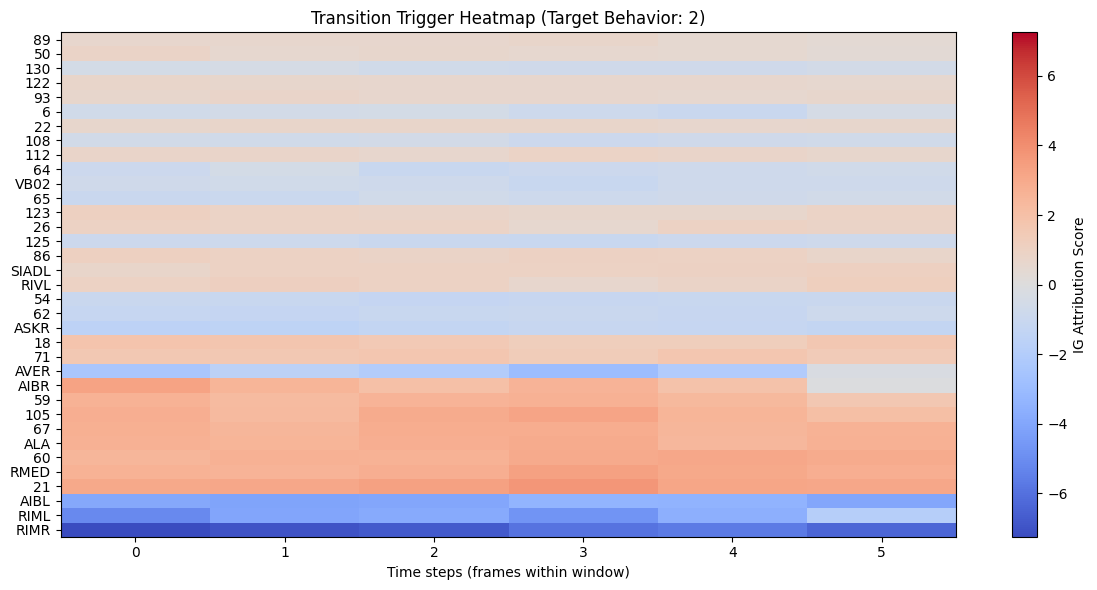

In [ ]:
transitions = np.where(b[:-1] != b[1:])[0]
t_idx = transitions[0] 
nowe_zachowanie = b[t_idx + 1]


start_idx = max(0, t_idx - 5)
end_idx = min(len(x_t_only), t_idx + 5)

wycinek_czasowy = torch.tensor(x_t_only[start_idx:end_idx], dtype=torch.float32, requires_grad=True)
ig_attr_wycinek = get_integrated_gradients(model, wycinek_czasowy, target_class=int(nowe_zachowanie))
ig_heatmap_data = ig_attr_wycinek.squeeze(1).T 

plot_transition_heatmap(
    ig_heatmap_data, 
    data.neuron_names, 
    top_n=35, 
    title=f"Transition Trigger Heatmap (Target Behavior: {nowe_zachowanie})"
)